In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_histograms(df, name):
    # Set the theme for seaborn plots
    sns.set_theme(style='darkgrid')

    # List of column names for Max and Mean values
    max_metrics = ['Dice_RCA_Max', 'L_Dice_RCA_Max', 'H_Dice_RCA_Max']
    mean_metrics = ['Dice_RCA_Mean', 'L_Dice_RCA_Mean', 'H_Dice_RCA_Mean']

    # Create a mapping for metric names to their full descriptions
    metric_description = {
        'Dice_RCA_Max': 'Max Dice RCA',
        'Dice_RCA_Mean': 'Mean Dice RCA',
    }

    # Create the 3x2 subplot
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    fig.tight_layout(pad=5)

    # Iterate through the Max and Mean metrics and create a histogram for each
    for i, (max_metric, mean_metric) in enumerate(zip(max_metrics, mean_metrics)):
        # Plot Max histogram
        sns.histplot(data=df, x=max_metric, kde=True, bins=20, ax=axes[i, 0])
        axes[i, 0].set_title(f'Histogram of {metric_description[max_metric]}')
        axes[i, 0].set_xlabel(metric_description[max_metric])
        axes[i, 0].set_ylabel('Frequency')

        # Plot Mean histogram
        sns.histplot(data=df, x=mean_metric, kde=True, bins=20, ax=axes[i, 1])
        axes[i, 1].set_title(f'Histogram of {metric_description[mean_metric]}')
        axes[i, 1].set_xlabel(metric_description[mean_metric])
        axes[i, 1].set_ylabel('Frequency')

    plt.suptitle("%s Dataset RCA Metrics Histograms" %name, fontsize=16)

In [32]:
df1 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/CANDID/CANDID_unet_RCA.csv')
name1 = 'CANDID'

df2 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/Chest8C/Chest8_unet_RCA.csv')
name2 = 'ChestX-Ray8'

df3 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/CheXpert/CheXpert_unet_RCA.csv')
name3 = 'CheXpert'

df4 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/MIMIC/MIMIC_unet_clean_RCA.csv')
name4 = "MIMIC"

df5 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/Padchest/Padchest_unet_RCA.csv')
name5 = 'Padchest'

df6 = pd.read_csv('/home/ngaggion/DATA/X-Ray/BigScale/Datasets/VinBigData/VinBigData_RCA.csv')
name6 = 'VinBigData'

In [33]:
def compute_statistics(df, metric_description):
    # Compute statistics for each metric
    stats = {}
    for metric, description in metric_description.items():
        stats[description] = {
            'mean': df[metric].mean(),
            'std': df[metric].std(),
            #'variance': df[metric].var(),
            'min': df[metric].min(),
            '25%': df[metric].quantile(0.25),
            '50%': df[metric].quantile(0.5),
            '75%': df[metric].quantile(0.75),
            'max': df[metric].max(),
            #'iqr': df[metric].quantile(0.75) - df[metric].quantile(0.25),
        }

    # Convert the dictionary to a pandas DataFrame
    stats_df = pd.DataFrame(stats)

    return stats_df

# Define the metric description dictionary
metric_description = {
    'Dice_RCA_Max': 'Max Dice RCA',
    'Dice_RCA_Mean': 'Mean Dice RCA',
}

def filter_images(df):
    return df[df['Dice_RCA_Max'] >= 0.7]

filtered_df1 = filter_images(df1)
filtered_df2 = filter_images(df2)
filtered_df3 = filter_images(df3)
filtered_df4 = filter_images(df4)
filtered_df5 = filter_images(df5)
filtered_df6 = filter_images(df6)

# Compute statistics for each dataset
filtered_stats_df1 = compute_statistics(filtered_df1, metric_description).T
filtered_stats_df2 = compute_statistics(filtered_df2, metric_description).T
filtered_stats_df3 = compute_statistics(filtered_df3, metric_description).T
filtered_stats_df4 = compute_statistics(filtered_df4, metric_description).T
filtered_stats_df5 = compute_statistics(filtered_df5, metric_description).T
filtered_stats_df6 = compute_statistics(filtered_df6, metric_description).T

def count_filtered_out(original_df, filtered_df):
    return len(original_df) - len(filtered_df)

filtered_out_count1 = count_filtered_out(df1, filtered_df1)
filtered_out_count2 = count_filtered_out(df2, filtered_df2)
filtered_out_count3 = count_filtered_out(df3, filtered_df3)
filtered_out_count4 = count_filtered_out(df4, filtered_df4)
filtered_out_count5 = count_filtered_out(df5, filtered_df5)
filtered_out_count6 = count_filtered_out(df6, filtered_df6)

def dataset_name_with_count_and_filtered(df, filtered_df, name):
    # Choose any metric to get the count, assuming all metrics have the same count
    count = df['Dice_RCA_Max'].count()
    filtered_count = count - filtered_df['Dice_RCA_Max'].count()
    return f"{name} (n = {count}, filtered = {filtered_count})"

# Update the dataset names with counts
name_1 = dataset_name_with_count_and_filtered(df1, filtered_df1, name1)
name_2 = dataset_name_with_count_and_filtered(df2, filtered_df2, name2)
name_3 = dataset_name_with_count_and_filtered(df3, filtered_df3, name3)
name_4 = dataset_name_with_count_and_filtered(df4, filtered_df4, name4)
name_5 = dataset_name_with_count_and_filtered(df5, filtered_df5, name5)
name_6 = dataset_name_with_count_and_filtered(df6, filtered_df6, name6)

# Combine the statistics DataFrames into a single DataFrame
stats_all = pd.concat([filtered_stats_df1, filtered_stats_df2, filtered_stats_df3, filtered_stats_df4, filtered_stats_df5, filtered_stats_df6], keys=[name_1, name_2, name_3, name_4, name_5, name_6])

In [36]:
def plot_individual_histograms(dfs, names):
    # Set the theme for seaborn plots
    sns.set_theme(style='darkgrid')

    # List of column names for Max and Mean values
    max_metrics = ['Dice_RCA_Max']
    mean_metrics = ['Dice_RCA_Mean']

    # Create a mapping for metric names to their full descriptions
    metric_description = {
        'Dice_RCA_Max': 'Max Dice RCA',
        'Dice_RCA_Mean': 'Mean Dice RCA'
    }

    # Create the subplot grid
    fig, axes = plt.subplots(len(dfs), 2, figsize=(12, len(dfs) * 3))
    fig.tight_layout(pad=5)

    # Iterate through the datasets and plot the histograms for Dice_RCA_Max and Dice_RCA_Mean
    for i, (df, name) in enumerate(zip(dfs, names)):
        max_values = df[max_metrics[0]]
        mean_values = df[mean_metrics[0]]

        # Plot Max histogram
        sns.histplot(data=max_values, kde=True, bins=20, ax=axes[i, 0], stat='density', color=sns.color_palette()[i], label=name)
        axes[i, 0].set_title(f'{metric_description["Dice_RCA_Max"]} Histogram for {name}')
        axes[i, 0].set_xlabel(metric_description['Dice_RCA_Max'])
        axes[i, 0].set_ylabel('Percentage')

        # Plot Mean histogram
        sns.histplot(data=mean_values, kde=True, bins=20, ax=axes[i, 1], stat='density', color=sns.color_palette()[i], label=name)
        axes[i, 1].set_title(f'{metric_description["Dice_RCA_Mean"]} Histogram for {name}')
        axes[i, 1].set_xlabel(metric_description['Dice_RCA_Mean'])
        axes[i, 1].set_ylabel('Percentage')

    # Add legends for the dataset colors
    for i in range(len(dfs)):
        axes[i, 0].legend()
        axes[i, 1].legend()

    # Add a title for the entire figure
    plt.suptitle("Dice RCA Max and Mean Metrics Histograms for All Datasets", fontsize=16)
    
    # Reduce the space between the subplots
    plt.subplots_adjust(hspace=0.4)
    plt.savefig('histograms.png', dpi=300, bbox_inches='tight')


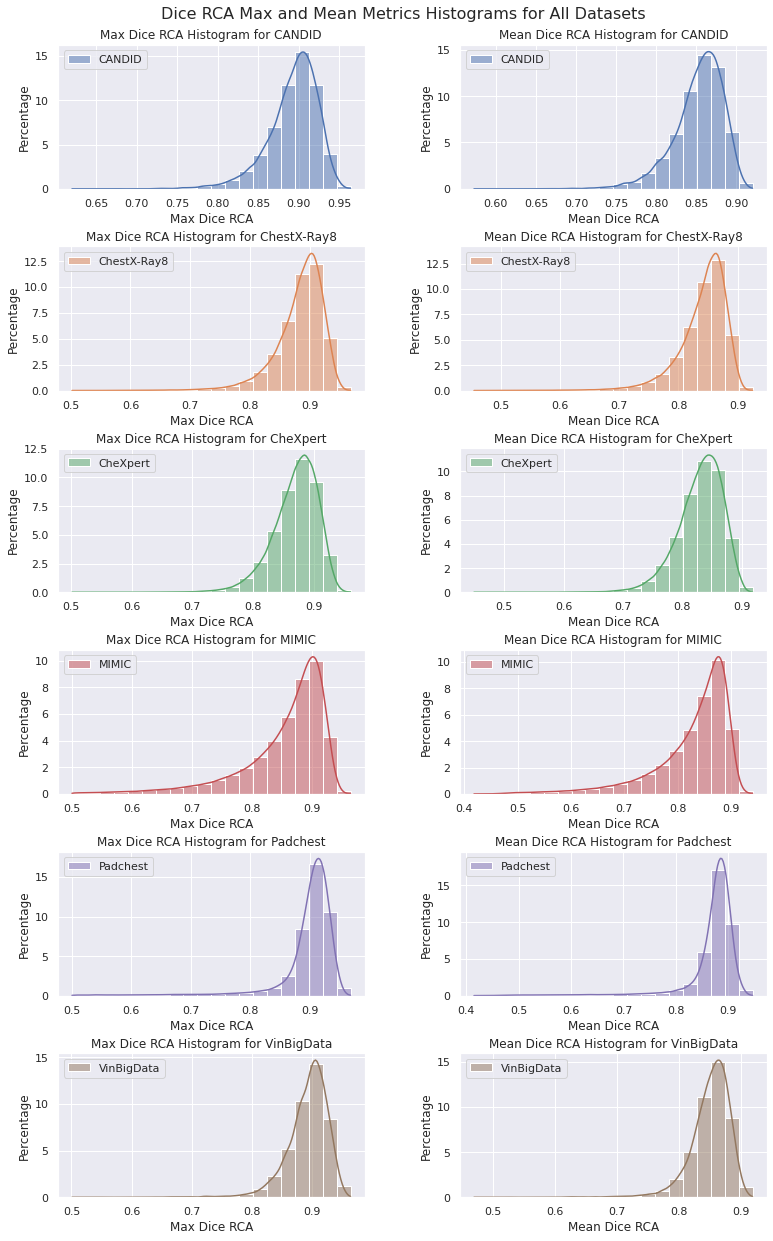

In [37]:
dfs = [filtered_df1, filtered_df2, filtered_df3, filtered_df4, filtered_df5, filtered_df6]
names = [name1, name2, name3, name4, name5, name6]

plot_individual_histograms(dfs, names)

In [40]:
# print all names
print(name_1)
print(name_2)
print(name_3)
print(name_4)
print(name_5)
print(name_6)


CANDID (n = 19235, filtered = 0)
ChestX-Ray8 (n = 112120, filtered = 83)
CheXpert (n = 187825, filtered = 10)
MIMIC (n = 243334, filtered = 2023)
Padchest (n = 96184, filtered = 802)
VinBigData (n = 18000, filtered = 0)


In [42]:
# Print the combined DataFrame
display(stats_all.round(3))

mean    std    min  \
CANDID (n = 19235, filtered = 0)        Max Dice RCA   0.893  0.031  0.620   
                                        Mean Dice RCA  0.853  0.031  0.573   
ChestX-Ray8 (n = 112120, filtered = 83) Max Dice RCA   0.882  0.042  0.502   
                                        Mean Dice RCA  0.841  0.042  0.454   
CheXpert (n = 187825, filtered = 10)    Max Dice RCA   0.870  0.038  0.502   
                                        Mean Dice RCA  0.830  0.038  0.449   
MIMIC (n = 243334, filtered = 2023)     Max Dice RCA   0.855  0.072  0.500   
                                        Mean Dice RCA  0.828  0.072  0.418   
Padchest (n = 96184, filtered = 802)    Max Dice RCA   0.898  0.053  0.500   
                                        Mean Dice RCA  0.870  0.054  0.415   
VinBigData (n = 18000, filtered = 0)    Max Dice RCA   0.892  0.035  0.501   
                                        Mean Dice RCA  0.850  0.033  0.469   

                                                         25%    50%    75%  \
CANDID (n = 19235, filtered = 0)        Max Dice RCA   0.877  0.898  0.914   
                                        Mean Dice RCA  0.837  0.858  0.875   
ChestX-Ray8 (n = 112120, filtered = 83) Max Dice RCA   0.864  0.890  0.909   
                                        Mean Dice RCA  0.823  0.850  0.869   
CheXpert (n = 187825, filtered = 10)    Max Dice RCA   0.849  0.875  0.896   
                                        Mean Dice RCA  0.808  0.835  0.857   
MIMIC (n = 243334, filtered = 2023)     Max Dice RCA   0.829  0.877  0.903   
                                        Mean Dice RCA  0.802  0.850  0.877   
Padchest (n = 96184, filtered = 802)    Max Dice RCA   0.891  0.909  0.923   
                                        Mean Dice RCA  0.865  0.882  0.895   
VinBigData (n = 18000, filtered = 0)    Max Dice RCA   0.876  0.898  0.915   
                                        Mean Dice RCA  0.835  0.855  0.872   

                                                         max  
CANDID (n = 19235, filtered = 0)        Max Dice RCA   0.964  
                                        Mean Dice RCA  0.920  
ChestX-Ray8 (n = 112120, filtered = 83) Max Dice RCA   0.967  
                                        Mean Dice RCA  0.925  
CheXpert (n = 187825, filtered = 10)    Max Dice RCA   0.961  
                                        Mean Dice RCA  0.918  
MIMIC (n = 243334, filtered = 2023)     Max Dice RCA   0.965  
                                        Mean Dice RCA  0.940  
Padchest (n = 96184, filtered = 802)    Max Dice RCA   0.969  
                                        Mean Dice RCA  0.946  
VinBigData (n = 18000, filtered = 0)    Max Dice RCA   0.964  
                                        Mean Dice RCA  0.919